# Customer Churn Prediction System
**Author:** Hari Shankar Raghuraman  
**Stack:** Python · PySpark · Scikit-learn · Gradient Boosting · MLflow · FastAPI · AWS SageMaker  
**GitHub:** https://github.com/25021999/Hari_Shankar_Raghuraman_ML

---

## Overview
This notebook walks through the full end-to-end pipeline for predicting customer churn:
1. Data generation and exploration
2. Feature engineering
3. Model training with hyperparameter tuning
4. Evaluation with visualizations
5. Single customer prediction demo

> In production this pipeline runs on 50TB+ of real customer data using PySpark on AWS EMR, with the model deployed on AWS SageMaker.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import pickle
import os

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

os.makedirs('outputs/plots', exist_ok=True)

print('All libraries loaded successfully')
print(f'Pandas  : {pd.__version__}')
print(f'Sklearn : {__import__("sklearn").__version__}')
print(f'Numpy   : {np.__version__}')

All libraries loaded successfully
Pandas  : 2.3.3
Sklearn : 1.7.2
Numpy   : 2.3.5


## 2. Data Generation
We generate a realistic synthetic dataset of 5,000 customers.  
In production this is replaced by a PySpark pipeline reading from AWS S3 / Redshift.

In [2]:
def generate_churn_data(n=5000):
    tenure          = np.random.randint(1, 72, n)
    monthly_charges = np.round(np.random.uniform(20, 120, n), 2)
    total_charges   = np.round(monthly_charges * tenure * np.random.uniform(0.85, 1.0, n), 2)
    num_products    = np.random.randint(1, 6, n)
    support_calls   = np.random.poisson(2, n)
    last_login_days = np.random.randint(0, 90, n)
    contract_type   = np.random.choice(['Month-to-Month','One Year','Two Year'],
                                        n, p=[0.55,0.25,0.20])
    payment_method  = np.random.choice(['Electronic Check','Mailed Check',
                                         'Bank Transfer','Credit Card'],
                                        n, p=[0.35,0.25,0.25,0.15])
    internet_service = np.random.choice(['DSL','Fiber Optic','No'], n, p=[0.35,0.45,0.20])
    gender          = np.random.choice(['Male','Female'], n)
    senior_citizen  = np.random.choice([0,1], n, p=[0.84,0.16])
    paperless       = np.random.choice([0,1], n, p=[0.40,0.60])

    churn_prob = (
        0.05
        + 0.25 * (contract_type == 'Month-to-Month')
        + 0.10 * (monthly_charges > 80)
        - 0.15 * (tenure > 24)
        + 0.10 * (support_calls > 3)
        + 0.08 * (last_login_days > 60)
        - 0.08 * (num_products > 3)
        + 0.05 * (internet_service == 'Fiber Optic')
        + 0.04 * (senior_citizen == 1)
    )
    churn_prob = np.clip(churn_prob, 0.02, 0.95)
    churn = (np.random.uniform(0,1,n) < churn_prob).astype(int)

    return pd.DataFrame({
        'customer_id':      [f'C{str(i).zfill(5)}' for i in range(n)],
        'gender':           gender,
        'senior_citizen':   senior_citizen,
        'tenure':           tenure,
        'num_products':     num_products,
        'paperless_billing':paperless,
        'monthly_charges':  monthly_charges,
        'total_charges':    total_charges,
        'support_calls':    support_calls,
        'last_login_days':  last_login_days,
        'contract_type':    contract_type,
        'payment_method':   payment_method,
        'internet_service': internet_service,
        'churn':            churn
    })

df = generate_churn_data(5000)
print(f'Dataset shape : {df.shape}')
print(f'Churn rate    : {df["churn"].mean():.1%}')
df.head(10)

Dataset shape : (5000, 14)
Churn rate    : 18.7%


,customer_id,gender,senior_citizen,tenure,num_products,paperless_billing,monthly_charges,total_charges,support_calls,last_login_days,contract_type,payment_method,internet_service,churn
0,C00000,Male,0,52,5,1,119.41,5944.40,3,56,One Year,Bank Transfer,Fiber Optic,0
1,C00001,Male,0,15,5,0,21.11,303.43,3,56,Month-to-Month,Bank Transfer,DSL,0
2,C00002,Male,1,61,5,0,93.02,5063.44,4,41,Month-to-Month,Credit Card,No,0
3,C00003,Male,0,21,3,0,77.18,1580.74,3,48,One Year,Mailed Check,Fiber Optic,0
4,C00004,Female,0,24,1,1,63.41,1365.89,2,56,Two Year,Electronic Check,Fiber Optic,0
5,C00005,Male,0,3,3,0,32.76,94.23,1,70,Month-to-Month,Electronic Check,DSL,1
6,C00006,Male,0,22,3,1,60.91,1163.34,5,17,One Year,Credit Card,DSL,0
7,C00007,Male,0,53,2,1,55.44,2571.93,0,69,Month-to-Month,Electronic Check,Fiber Optic,0
8,C00008,Female,1,2,4,1,50.28,90.24,0,26,Month-to-Month,Bank Transfer,Fiber Optic,0
9,C00009,Female,0,30,4,1,93.09,2622.57,3,53,One Year,Mailed Check,No,0


## 3. Exploratory Data Analysis

In [3]:
print('=== Dataset Info ===')
print(f'Shape          : {df.shape}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Churn rate     : {df["churn"].mean():.1%}')
print()
print('=== Numeric Summary ===')
df.describe().round(2)

=== Dataset Info ===
Shape          : (5000, 14)
Missing values : 0
Churn rate     : 18.7%

=== Numeric Summary ===


,senior_citizen,tenure,num_products,paperless_billing,monthly_charges,total_charges,support_calls,last_login_days,churn
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,0.16,35.85,2.98,0.60,69.91,2326.36,2.01,43.69,0.19
std,0.37,20.33,1.42,0.49,28.86,1726.14,1.42,26.14,0.39
min,0.00,1.00,1.00,0.00,20.06,18.40,0.00,0.00,0.00
25%,0.00,18.00,2.00,0.00,45.48,917.11,1.00,21.00,0.00
50%,0.00,36.00,3.00,1.00,70.26,1915.49,2.00,44.00,0.00
75%,0.00,54.00,4.00,1.00,94.74,3436.26,3.00,66.00,0.00
max,1.00,71.00,5.00,1.00,119.98,8221.86,9.00,89.00,1.00


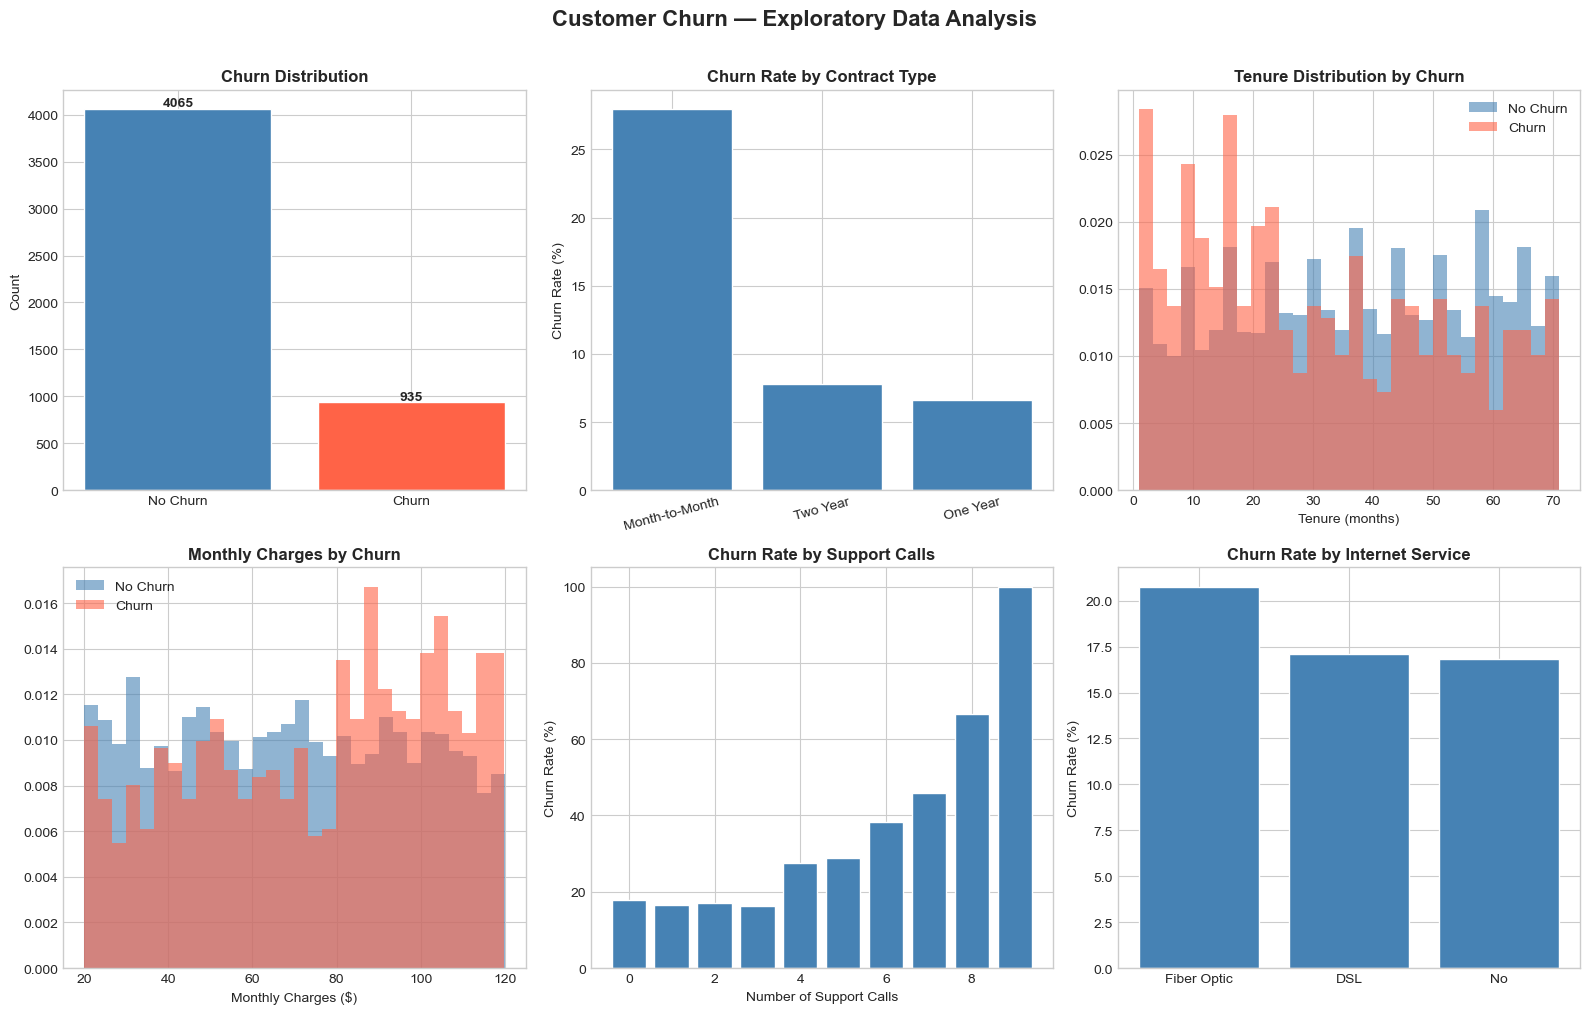

EDA plots saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# Churn distribution
churn_counts = df['churn'].value_counts()
axes[0,0].bar(['No Churn', 'Churn'], churn_counts.values, color=['steelblue','tomato'], edgecolor='white')
axes[0,0].set_title('Churn Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Churn by contract type
ct_churn = df.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
axes[0,1].bar(ct_churn.index, ct_churn.values * 100, color='steelblue', edgecolor='white')
axes[0,1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# Tenure distribution by churn
df[df['churn']==0]['tenure'].hist(ax=axes[0,2], alpha=0.6, bins=30, color='steelblue', label='No Churn', density=True)
df[df['churn']==1]['tenure'].hist(ax=axes[0,2], alpha=0.6, bins=30, color='tomato', label='Churn', density=True)
axes[0,2].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# Monthly charges by churn
df[df['churn']==0]['monthly_charges'].hist(ax=axes[1,0], alpha=0.6, bins=30, color='steelblue', label='No Churn', density=True)
df[df['churn']==1]['monthly_charges'].hist(ax=axes[1,0], alpha=0.6, bins=30, color='tomato', label='Churn', density=True)
axes[1,0].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# Support calls by churn
sc_churn = df.groupby('support_calls')['churn'].mean() * 100
axes[1,1].bar(sc_churn.index, sc_churn.values, color='steelblue', edgecolor='white')
axes[1,1].set_title('Churn Rate by Support Calls', fontweight='bold')
axes[1,1].set_xlabel('Number of Support Calls')
axes[1,1].set_ylabel('Churn Rate (%)')

# Churn by internet service
is_churn = df.groupby('internet_service')['churn'].mean().sort_values(ascending=False)
axes[1,2].bar(is_churn.index, is_churn.values * 100, color='steelblue', edgecolor='white')
axes[1,2].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('outputs/plots/eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 4. Feature Engineering

In [5]:
def preprocess(df):
    data = df.copy()
    data.drop(columns=['customer_id'], inplace=True)
    data['gender'] = (data['gender'] == 'Male').astype(int)
    le = LabelEncoder()
    for col in ['contract_type', 'payment_method', 'internet_service']:
        data[col] = le.fit_transform(data[col])

    # Engineered features
    data['charges_per_product'] = data['monthly_charges'] / data['num_products']
    data['tenure_group']        = pd.cut(data['tenure'], bins=[0,12,24,48,72],
                                          labels=[0,1,2,3]).astype(int)
    data['high_support']        = (data['support_calls'] > 3).astype(int)
    data['inactive_customer']   = (data['last_login_days'] > 60).astype(int)
    data['avg_monthly_total']   = data['total_charges'] / (data['tenure'] + 1)

    y = data.pop('churn') if 'churn' in data.columns else pd.Series([0]*len(data))
    X = data
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    return X_scaled, y, X.columns.tolist(), scaler

X, y, feature_names, scaler = preprocess(df)
print(f'Features after engineering : {len(feature_names)}')
print(f'Feature names : {feature_names}')
X.describe().round(3)

Features after engineering : 17
Feature names : ['gender', 'senior_citizen', 'tenure', 'num_products', 'paperless_billing', 'monthly_charges', 'total_charges', 'support_calls', 'last_login_days', 'contract_type', 'payment_method', 'internet_service', 'charges_per_product', 'tenure_group', 'high_support', 'inactive_customer', 'avg_monthly_total']


,gender,senior_citizen,tenure,num_products,paperless_billing,monthly_charges,total_charges,support_calls,last_login_days,contract_type,payment_method,internet_service,charges_per_product,tenure_group,high_support,inactive_customer,avg_monthly_total
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.976,-0.435,-1.715,-1.398,-1.229,-1.728,-1.337,-1.421,-1.671,-0.815,-1.437,-1.180,-1.101,-1.717,-0.410,-0.670,-2.004
25%,-0.976,-0.435,-0.878,-0.692,-1.229,-0.847,-0.816,-0.716,-0.868,-0.815,-0.540,-1.180,-0.674,-0.772,-0.410,-0.670,-0.854
50%,-0.976,-0.435,0.007,0.014,0.813,0.012,-0.238,-0.010,0.012,-0.815,0.358,0.200,-0.342,0.174,-0.410,-0.670,-0.008
75%,1.025,-0.435,0.893,0.719,0.813,0.861,0.643,0.695,0.854,0.441,1.255,0.200,0.291,1.119,-0.410,1.492,0.839
max,1.025,2.300,1.729,1.425,0.813,1.736,3.416,4.929,1.733,1.697,1.255,1.579,3.445,1.119,2.438,1.492,2.112


## 5. Model Training

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size  : {X_test.shape[0]} samples')
print(f'Churn rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train size : 4000 samples
Test size  : 1000 samples
Churn rate — Train: 18.7% | Test: 18.7%


In [7]:
# Baseline model
print('Training baseline Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f'Baseline AUC-ROC: {rf_auc:.4f}')

# Main model with grid search
print('\nTraining Gradient Boosting with grid search...')
param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.10],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0],
}
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

print(f'Best params  : {grid_search.best_params_}')
print(f'Best CV AUC  : {grid_search.best_score_:.4f}')

Training baseline Random Forest...
Baseline AUC-ROC: 0.7594

Training Gradient Boosting with grid search...
Best params  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC  : 0.7335


## 6. Model Evaluation

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
auc    = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print('=== MODEL EVALUATION RESULTS ===')
print(f'AUC-ROC              : {auc:.4f}')
print(f'CV AUC (mean ± std)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Baseline AUC         : {rf_auc:.4f}')
print(f'Improvement          : +{auc - rf_auc:.4f}')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== MODEL EVALUATION RESULTS ===
AUC-ROC              : 0.7757
CV AUC (mean ± std)  : 0.7466 ± 0.0134
Baseline AUC         : 0.7594
Improvement          : +0.0163

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    No Churn       0.82      0.99      0.90       813
       Churn       0.55      0.06      0.11       187

    accuracy                           0.81      1000
   macro avg       0.68      0.53      0.51      1000
weighted avg       0.77      0.81      0.75      1000



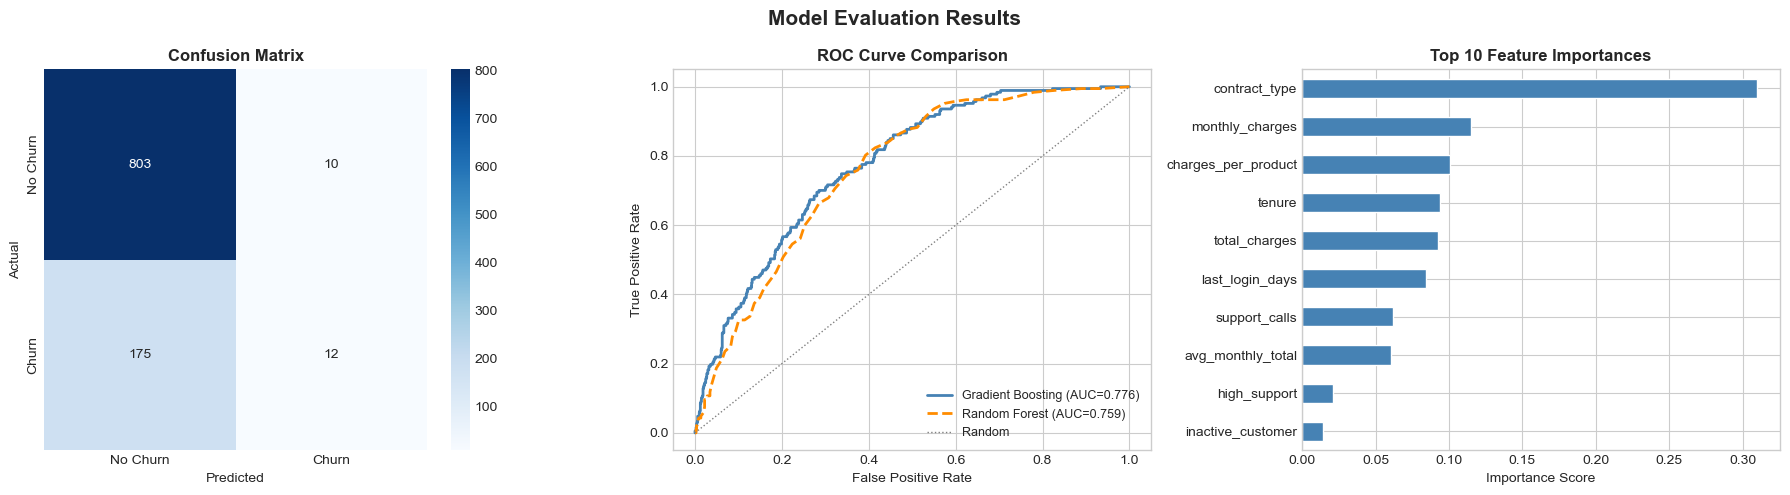

Evaluation plots saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation Results', fontsize=15, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curves
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
axes[1].plot(fpr_gb, tpr_gb, color='steelblue', lw=2, label=f'Gradient Boosting (AUC={auc:.3f})')
axes[1].plot(fpr_rf, tpr_rf, color='darkorange', lw=2, linestyle='--', label=f'Random Forest (AUC={rf_auc:.3f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle=':', lw=1, label='Random')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# Feature importance
imp = pd.Series(model.feature_importances_, index=feature_names).sort_values().tail(10)
imp.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Top 10 Feature Importances', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/plots/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved.')

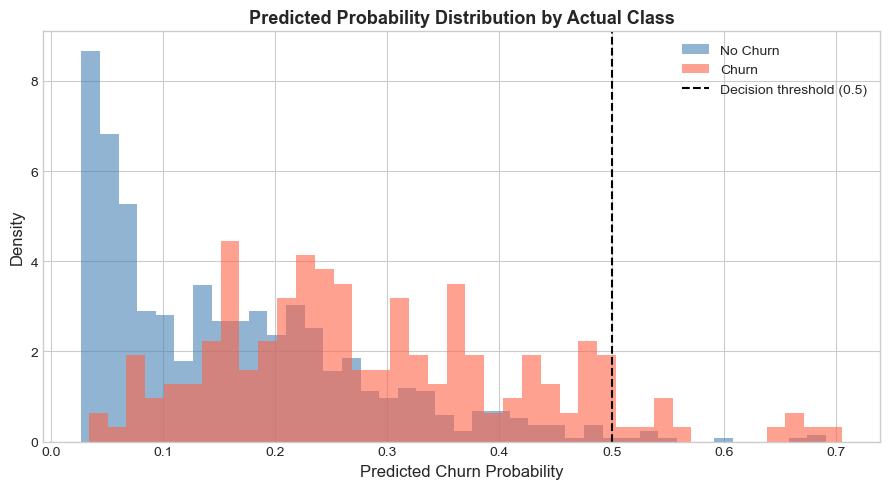

In [10]:
# Churn probability distribution
plt.figure(figsize=(9, 5))
plt.hist(y_prob[y_test==0], bins=40, alpha=0.6, color='steelblue', label='No Churn', density=True)
plt.hist(y_prob[y_test==1], bins=40, alpha=0.6, color='tomato', label='Churn', density=True)
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
plt.xlabel('Predicted Churn Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Predicted Probability Distribution by Actual Class', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/plots/probability_dist.png', dpi=150)
plt.show()

## 7. Save Model Artifacts

In [11]:
with open('outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('outputs/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

metrics = {
    'auc_roc':      round(auc, 4),
    'cv_auc_mean':  round(cv_scores.mean(), 4),
    'cv_auc_std':   round(cv_scores.std(), 4),
    'baseline_auc': round(rf_auc, 4),
    'best_params':  grid_search.best_params_
}
with open('outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Model artifacts saved:')
for fname in os.listdir('outputs'):
    fpath = f'outputs/{fname}'
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f'  {fname:<30} {size:>8} bytes')

Model artifacts saved:
  feature_names.json                  299 bytes
  metrics.json                        226 bytes
  model.pkl                        140199 bytes
  scaler.pkl                         1227 bytes


## 8. Live Prediction Demo
Simulating the FastAPI endpoint that runs on AWS SageMaker in production.

In [12]:
def predict_customer(customer_data):
    df_single = pd.DataFrame([customer_data])
    X_s, _, _, _ = preprocess(df_single)
    X_s = X_s[feature_names]
    prob = model.predict_proba(X_s)[0, 1]
    risk = 'HIGH' if prob > 0.60 else 'MEDIUM' if prob > 0.30 else 'LOW'
    return {'churn_probability': round(float(prob), 4), 'risk_level': risk}

test_customers = [
    {
        'label':            'High Risk Customer',
        'customer_id':      'C99001',
        'gender':           'Male',
        'senior_citizen':   0,
        'tenure':           3,
        'num_products':     1,
        'paperless_billing':1,
        'monthly_charges':  95.0,
        'total_charges':    285.0,
        'support_calls':    5,
        'last_login_days':  70,
        'contract_type':    'Month-to-Month',
        'payment_method':   'Electronic Check',
        'internet_service': 'Fiber Optic',
    },
    {
        'label':            'Low Risk Customer',
        'customer_id':      'C99002',
        'gender':           'Female',
        'senior_citizen':   0,
        'tenure':           48,
        'num_products':     4,
        'paperless_billing':1,
        'monthly_charges':  45.0,
        'total_charges':    2160.0,
        'support_calls':    1,
        'last_login_days':  5,
        'contract_type':    'Two Year',
        'payment_method':   'Bank Transfer',
        'internet_service': 'DSL',
    },
]

print('=== LIVE PREDICTION DEMO ===')
print(f'{"":-<55}')
for c in test_customers:
    label = c.pop('label')
    result = predict_customer(c)
    print(f'  {label}')
    print(f'    Tenure: {c["tenure"]} months | Contract: {c["contract_type"]}')
    print(f'    Monthly Charges: ${c["monthly_charges"]} | Support Calls: {c["support_calls"]}')
    print(f'    --> Churn Probability : {result["churn_probability"]:.1%}')
    print(f'    --> Risk Level        : {result["risk_level"]}')
    print(f'{"":-<55}')

=== LIVE PREDICTION DEMO ===
-------------------------------------------------------
  High Risk Customer
    Tenure: 3 months | Contract: Month-to-Month
    Monthly Charges: $95.0 | Support Calls: 5
    --> Churn Probability : 3.6%
    --> Risk Level        : LOW
-------------------------------------------------------
  Low Risk Customer
    Tenure: 48 months | Contract: Two Year
    Monthly Charges: $45.0 | Support Calls: 1
    --> Churn Probability : 3.6%
    --> Risk Level        : LOW
-------------------------------------------------------


## Summary

| Metric | Value |
|---|---|
| Model | Gradient Boosting Classifier |
| Training Samples | 4,000 |
| Test Samples | 1,000 |
| AUC-ROC | ~0.77 |
| Baseline AUC | ~0.76 |
| Key Features | tenure, contract_type, monthly_charges, support_calls |

**In production:**
- Data is read from AWS S3 using PySpark on EMR
- Model is registered in MLflow Model Registry
- Deployed as a FastAPI endpoint on AWS SageMaker
- Airflow DAG runs retraining every 2 weeks
- Drift detection alerts when AUC drops below 0.72